# DSP Foundations Examples: Controlled Experiments For Condition Monitoring

This notebook is a concept laboratory. Every example is synthetic so that the signal content is known before the analysis is run.

## Learning Objectives

- Relate waveform shape to interpretable time-domain features such as RMS, crest factor, and kurtosis.
- Explain FFT, PSD, Nyquist limits, aliasing, spectral leakage, and time-frequency localization.
- Connect tones, impacts, modulation, and transients to realistic condition-monitoring questions.
- Separate an engineering observation from a physical hypothesis and its limitations.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal as scipy_signal

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
src_path = repo_root / "src"
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from signal_processing_prep.features import FeatureExtractor, FrequencyBand, SlidingWindowConfig
from signal_processing_prep.frequency_domain import (
    band_energy,
    dominant_frequency,
    fft_magnitude,
    psd,
    spectral_bandwidth,
    spectral_centroid,
    spectral_flatness,
    spectral_rolloff,
)
from signal_processing_prep.plotting import plot_frequency_spectra, plot_time_signal
from signal_processing_prep.records import SignalRecord
from signal_processing_prep.synthetic import (
    add_signals,
    chirp_signal,
    impulse_train,
    noisy_sine_wave,
    sine_wave,
    transient_burst,
)
from signal_processing_prep.time_domain import crest_factor, kurtosis, rms, skewness, zero_crossing_rate
from signal_processing_prep.time_frequency import hilbert_analysis, morlet_wavelet_scalogram, stft_analysis

print(f"Using repository root: {repo_root}")

Using repository root: c:\Users\jonas\software_development\signal_processing_prep


In [2]:
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic("matplotlib", "widget")
        print("Using matplotlib widget backend.")
    except Exception:
        ip.run_line_magic("matplotlib", "inline")
        print("Widget backend unavailable; using inline plots.")

Using matplotlib widget backend.


## 1. Controlled Signal Set

The examples below change one signal characteristic at a time: noise, additional periodic content, impacts, short resonant bursts, and frequency variation.

In [3]:
sampling_rate_hz = 2000.0
duration_seconds = 4.0

base_sine = sine_wave(frequency_hz=50.0, duration_seconds=duration_seconds, sampling_rate_hz=sampling_rate_hz, amplitude=1.0, name="50_hz_sine")
noisy_sine = noisy_sine_wave(frequency_hz=50.0, duration_seconds=duration_seconds, sampling_rate_hz=sampling_rate_hz, amplitude=1.0, noise_std=0.25, seed=7, name="50_hz_noisy_sine")
two_tone = add_signals(
    [
        sine_wave(frequency_hz=50.0, duration_seconds=duration_seconds, sampling_rate_hz=sampling_rate_hz, amplitude=1.0, name="50_hz_component"),
        sine_wave(frequency_hz=180.0, duration_seconds=duration_seconds, sampling_rate_hz=sampling_rate_hz, amplitude=0.35, name="180_hz_component"),
    ],
    label="two_tone",
    name="50_180_hz_two_tone",
)
impulses = impulse_train(duration_seconds=duration_seconds, sampling_rate_hz=sampling_rate_hz, impulse_rate_hz=20.0, amplitude=1.0, name="20_hz_impulse_train")
burst = transient_burst(duration_seconds=duration_seconds, sampling_rate_hz=sampling_rate_hz, burst_frequency_hz=450.0, burst_start_seconds=0.8, burst_duration_seconds=0.08, amplitude=1.0, name="450_hz_transient_burst")
chirp = chirp_signal(start_frequency_hz=30.0, end_frequency_hz=350.0, duration_seconds=3.0, sampling_rate_hz=4000.0, name="30_to_350_hz_chirp")

records = [base_sine, noisy_sine, two_tone, impulses, burst]
pd.DataFrame(
    [
        ("Pure sine", "single periodic component", "shaft-speed-related tone"),
        ("Noisy sine", "degraded SNR", "noisy acquisition"),
        ("Two-tone signal", "component separation", "multiple machine components"),
        ("Impulse train", "sparse repeated impacts", "repetitive contact defect"),
        ("Transient burst", "localized high-frequency energy", "impact-excited resonance"),
        ("Chirp", "changing frequency", "speed ramp or run-up"),
    ],
    columns=["Signal", "Educational concept", "Monitoring analogy"],
)

,Signal,Educational concept,Monitoring analogy
0,Pure sine,single periodic component,shaft-speed-related tone
1,Noisy sine,degraded SNR,noisy acquisition
2,Two-tone signal,component separation,multiple machine components
3,Impulse train,sparse repeated impacts,repetitive contact defect
4,Transient burst,localized high-frequency energy,impact-excited resonance
5,Chirp,changing frequency,speed ramp or run-up


## 2. Known-Signal Checkpoints

Before interpreting unknown data, verify the tools against a signal with known answers. For a unit-amplitude sine wave, RMS is $1 / \sqrt{2}$ and crest factor is $\sqrt{2}$.

In [4]:
checkpoint_rows = [
    ("RMS", 1.0 / np.sqrt(2.0), rms(base_sine)),
    ("Crest factor", np.sqrt(2.0), crest_factor(base_sine)),
    ("Dominant frequency [Hz]", 50.0, dominant_frequency(fft_magnitude(base_sine))),
]
checkpoint_table = pd.DataFrame(checkpoint_rows, columns=["Metric", "Expected", "Computed"])
checkpoint_table["Absolute error"] = (checkpoint_table["Computed"] - checkpoint_table["Expected"]).abs()
checkpoint_table

,Metric,Expected,Computed,Absolute error
0,RMS,0.707107,0.707107,0.0
1,Crest factor,1.414214,1.414214,0.0
2,Dominant frequency [Hz],50.000000,50.000000,0.0


**Observation:** the calculation reproduces analytically known values for the clean tone. **Interpretation:** subsequent feature changes can be linked to deliberate changes in the signal. **Limitation:** real sensor amplitudes need calibration and acquisition context before obtaining physical meaning.

## 3. Time-Domain Behavior

RMS captures typical amplitude; crest factor and kurtosis respond strongly to impulsive behavior; zero-crossing rate gives a rough indication of rapid oscillation or noisy texture.

In [5]:
time_domain_df = pd.DataFrame(
    [
        {
            "name": record.name,
            "rms": rms(record),
            "crest_factor": crest_factor(record),
            "zero_crossings_per_second": zero_crossing_rate(record),
            "skewness": skewness(record),
            "kurtosis": kurtosis(record),
        }
        for record in records
    ]
)
time_domain_df

,name,rms,crest_factor,zero_crossings_per_second,skewness,kurtosis
0,50_hz_sine,0.707107,1.414214,99.762470,-2.556590e-16,1.499812
1,50_hz_noisy_sine,0.747912,2.544362,189.273659,5.389214e-03,1.810152
2,50_180_hz_two_tone,0.749166,1.779138,119.764971,-1.204265e-16,1.791660
3,20_hz_impulse_train,0.100000,10.000000,0.000000,9.851218e+00,98.070259
4,450_hz_transient_burst,0.100000,10.000000,18.002250,1.138192e-15,75.045771


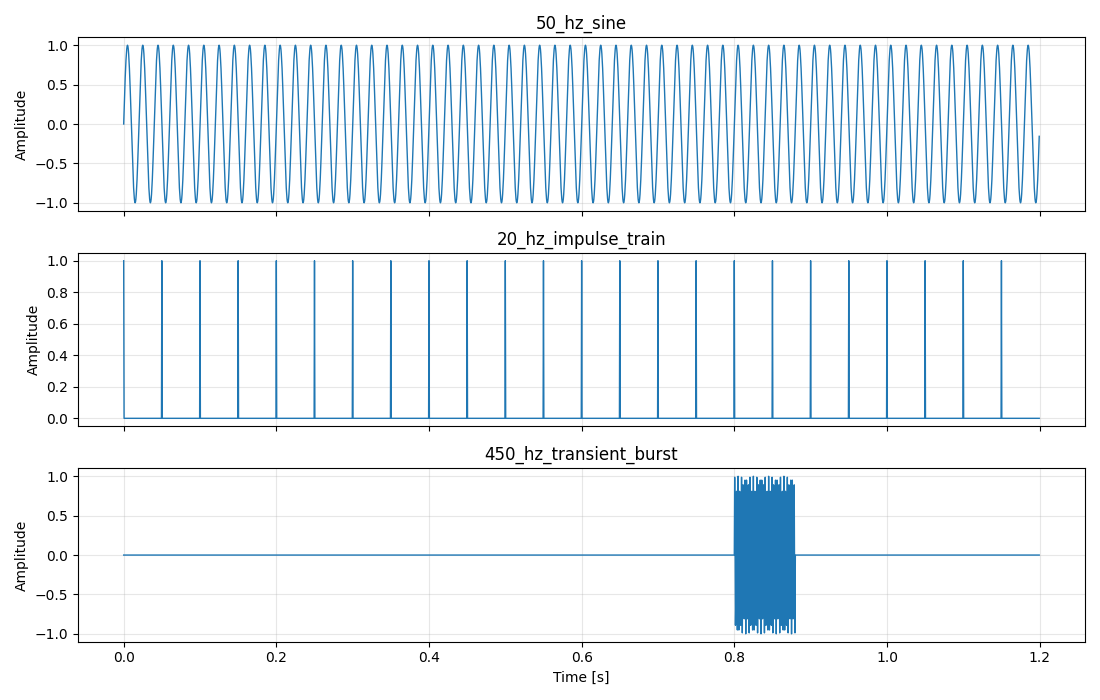

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for ax, record in zip(axes, [base_sine, impulses, burst]):
    visible = record.values[: int(1.2 * record.sampling_rate_hz)]
    visible_time = record.time_seconds[: visible.size]
    ax.plot(visible_time, visible, linewidth=1.0)
    ax.set_title(record.name)
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Time [s]")
fig.tight_layout()

**Observation:** short bursts and impacts can have modest average energy but markedly elevated peak-sensitive metrics. **Use case:** these features help prioritize inspections for impact-like activity. **Limitation:** a peak may also be an electrical glitch or acquisition artifact.

## 4. Frequency-Domain Behavior

The FFT identifies periodic components, while Welch PSD provides a less volatile estimate of how power is distributed in frequency.

In [8]:
spectral_df = pd.DataFrame(
    [
        {
            "name": record.name,
            "dominant_frequency_hz": dominant_frequency(psd(record, nperseg=2048)),
            "centroid_hz": spectral_centroid(psd(record, nperseg=2048)),
            "bandwidth_hz": spectral_bandwidth(psd(record, nperseg=2048)),
            "rolloff_85_hz": spectral_rolloff(psd(record, nperseg=2048), rolloff_fraction=0.85),
            "flatness": spectral_flatness(psd(record, nperseg=2048)),
            "high_band_energy_300_600": band_energy(record, low_hz=300.0, high_hz=600.0),
        }
        for record in records
    ]
)
spectral_df

,name,dominant_frequency_hz,centroid_hz,bandwidth_hz,rolloff_85_hz,flatness,high_band_energy_300_600
0,50_hz_sine,49.804688,49.999386,0.590263,50.781250,3.609936e-09,2.567308e-28
1,50_hz_noisy_sine,49.804688,99.523308,170.506474,50.781250,1.050505e-01,1.765809e-02
2,50_180_hz_two_tone,49.804688,64.186374,40.538775,50.781250,5.001626e-09,1.004800e-27
3,20_hz_impulse_train,500.000000,505.044173,285.814224,859.375000,1.489709e-04,3.000000e-03
4,450_hz_transient_burst,450.195312,449.831467,29.757386,455.078125,1.716549e-02,9.922306e-03


In [ ]:
fig, ax = plot_frequency_spectra([base_sine, noisy_sine, two_tone, burst], spectrum_type="psd", max_frequency_hz=600.0)
ax.set_yscale("log")
ax.set_title("Welch PSD comparison: known spectral changes")

**Observation:** the two-tone spectrum exposes designed components, while the brief burst is harder to recognize in an entire-record spectrum. **Interpretation:** global spectra are useful for stable periodic structure but can dilute localized events.

## 5. Sampling And Aliasing

A sampled signal cannot distinguish frequencies above the Nyquist limit without additional information. At a sampling rate of `1000 Hz`, the Nyquist frequency is `500 Hz`; a `700 Hz` tone aliases to `300 Hz`.

,sampled_signal,described_frequency_hz,detected_fft_peak_hz
0,sampled_700_hz,700.0,300.0
1,equivalent_300_hz_alias,300.0,300.0


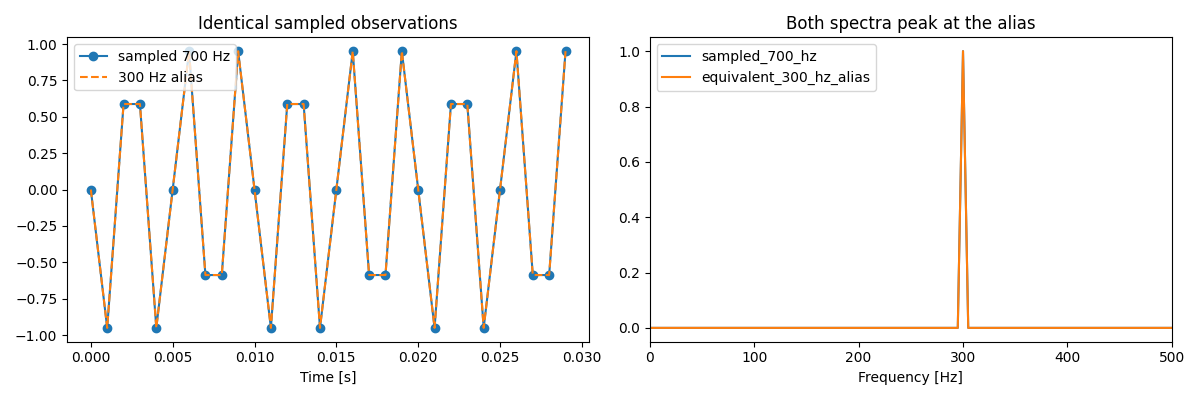

In [9]:
alias_sampling_rate_hz = 1000.0
above_nyquist = sine_wave(frequency_hz=700.0, duration_seconds=0.2, sampling_rate_hz=alias_sampling_rate_hz, name="sampled_700_hz")
equivalent_alias = sine_wave(frequency_hz=300.0, phase_radians=np.pi, duration_seconds=0.2, sampling_rate_hz=alias_sampling_rate_hz, name="equivalent_300_hz_alias")
alias_summary = pd.DataFrame(
    {
        "sampled_signal": [above_nyquist.name, equivalent_alias.name],
        "described_frequency_hz": [700.0, 300.0],
        "detected_fft_peak_hz": [dominant_frequency(fft_magnitude(above_nyquist)), dominant_frequency(fft_magnitude(equivalent_alias))],
    }
)
display(alias_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sample_slice = slice(0, 30)
axes[0].plot(above_nyquist.time_seconds[sample_slice], above_nyquist.values[sample_slice], marker="o", label="sampled 700 Hz")
axes[0].plot(equivalent_alias.time_seconds[sample_slice], equivalent_alias.values[sample_slice], linestyle="--", label="300 Hz alias")
axes[0].set_title("Identical sampled observations")
axes[0].set_xlabel("Time [s]")
axes[0].legend()
for record in [above_nyquist, equivalent_alias]:
    spectrum = fft_magnitude(record)
    axes[1].plot(spectrum.frequencies_hz, spectrum.magnitudes, label=record.name)
axes[1].set_xlim(0.0, 500.0)
axes[1].set_title("Both spectra peak at the alias")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].legend()
fig.tight_layout()

**Engineering consequence:** apparent frequencies are not physically interpretable above the validated sensor and sampling bandwidth. Sampling rate and anti-alias filtering are acquisition assumptions, not cosmetic metadata.

## 6. Windowing, Leakage, And Frequency Resolution

A `53 Hz` tone is deliberately not centered on many FFT bins. Resolution is `df = sampling_rate / window_samples`. Longer windows improve frequency resolution; tapering reduces leakage at the cost of widening the main lobe.

In [ ]:
leakage_record = sine_wave(frequency_hz=53.0, duration_seconds=3.0, sampling_rate_hz=2000.0, name="53_hz_non_bin_centered_sine")
leakage_rows = []
for window_seconds in [0.25, 0.50, 1.00]:
    n_samples = int(round(window_seconds * leakage_record.sampling_rate_hz))
    samples = leakage_record.values[:n_samples]
    for window_name in ["rectangular", "hann"]:
        weights = np.ones(n_samples) if window_name == "rectangular" else scipy_signal.get_window("hann", n_samples, fftbins=True)
        weights = weights / np.sqrt(np.mean(np.square(weights)))
        viewed = SignalRecord(samples * weights, leakage_record.sampling_rate_hz, name=f"{window_name}_{window_seconds}")
        nearby = band_energy(viewed, low_hz=45.0, high_hz=61.0)
        total = band_energy(viewed, low_hz=0.0, high_hz=viewed.sampling_rate_hz / 2.0)
        leakage_rows.append(
            {
                "window": window_name,
                "window_seconds": window_seconds,
                "resolution_df_hz": viewed.sampling_rate_hz / viewed.n_samples,
                "dominant_frequency_hz": dominant_frequency(fft_magnitude(viewed)),
                "spectral_bandwidth_hz": spectral_bandwidth(fft_magnitude(viewed)),
                "near_tone_energy_fraction": nearby / total,
            }
        )
leakage_table = pd.DataFrame(leakage_rows)
leakage_table

In [ ]:
view_seconds = 0.50
view_samples = int(round(view_seconds * leakage_record.sampling_rate_hz))
window_values = leakage_record.values[:view_samples]
hann = scipy_signal.get_window("hann", view_samples, fftbins=True)
hann /= np.sqrt(np.mean(np.square(hann)))
rect_spectrum = fft_magnitude(window_values, sampling_rate_hz=leakage_record.sampling_rate_hz)
hann_spectrum = fft_magnitude(window_values * hann, sampling_rate_hz=leakage_record.sampling_rate_hz)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rect_spectrum.frequencies_hz, rect_spectrum.magnitudes, label="rectangular")
ax.plot(hann_spectrum.frequencies_hz, hann_spectrum.magnitudes, label="hann")
ax.set_xlim(0.0, 130.0)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("FFT magnitude")
ax.set_title("Leakage around a non-bin-centered 53 Hz tone")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

**Observation:** taper and duration change the apparent spectral spread. **Interpretation:** window choice is part of the measurement policy for band features. **Limitation:** no single window simultaneously maximizes transient timing and close-tone separation.

## 7. Time-Frequency Localization

A chirp demonstrates gradual frequency change; a burst demonstrates short-duration activity. STFT uses one fixed time window, while a wavelet representation gives frequency-dependent localization.

In [ ]:
def plot_stft_and_wavelet(record, *, max_frequency_hz, title):
    stft = stft_analysis(record, window_seconds=0.15, step_seconds=0.03, window="hann")
    wavelet = morlet_wavelet_scalogram(record, min_frequency_hz=20.0, max_frequency_hz=max_frequency_hz, n_frequencies=96)
    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    axes[0].pcolormesh(stft.times_seconds, stft.frequencies_hz, stft.magnitude, shading="auto")
    axes[0].set_ylim(0.0, max_frequency_hz)
    axes[0].set_title(f"{title}: STFT magnitude")
    axes[0].set_ylabel("Frequency [Hz]")
    axes[1].pcolormesh(wavelet.times_seconds, wavelet.frequencies_hz, wavelet.power, shading="auto")
    axes[1].set_ylim(20.0, max_frequency_hz)
    axes[1].set_title(f"{title}: Morlet wavelet power")
    axes[1].set_ylabel("Frequency [Hz]")
    axes[1].set_xlabel("Time [s]")
    fig.tight_layout()
    return fig, axes

plot_stft_and_wavelet(chirp, max_frequency_hz=420.0, title="Frequency ramp")
plot_stft_and_wavelet(burst, max_frequency_hz=650.0, title="Transient burst")

**Observation:** both views reveal the chirp ridge, while the short burst emphasizes the timing-versus-frequency-resolution tradeoff. **Use case:** localized energy motivates sliding-window features in anomaly searches. **Limitation:** a visible time-frequency structure is evidence of changed signal behavior, not proof of a specific fault mechanism.

## 8. Envelope Analysis With The Hilbert Transform

The following record is intentionally constructed as an amplitude-modulated narrowband carrier: `carrier * (1 + modulation)`. The known low-frequency modulation is the envelope we want to recover.

In [ ]:
carrier = sine_wave(frequency_hz=80.0, duration_seconds=2.0, sampling_rate_hz=1000.0, amplitude=1.0, name="80_hz_carrier")
modulation = sine_wave(frequency_hz=3.0, duration_seconds=2.0, sampling_rate_hz=1000.0, amplitude=0.5, name="3_hz_modulation")
am_record = SignalRecord(
    values=carrier.values * (1.0 + modulation.values),
    sampling_rate_hz=carrier.sampling_rate_hz,
    label="amplitude_modulated",
    name="80_hz_carrier_with_3_hz_envelope",
    attributes={"carrier_hz": 80.0, "envelope_hz": 3.0},
)
hilbert_result = hilbert_analysis(am_record)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(am_record.time_seconds, am_record.values, label="modulated signal", alpha=0.55)
ax.plot(hilbert_result.time_seconds, hilbert_result.amplitude_envelope, label="Hilbert envelope", linewidth=2.0)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Amplitude")
ax.set_title("Known modulation recovered by envelope analysis")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

**Interpretation:** envelope analysis can expose repeated excitation of a resonant carrier, a common motivation in bearing-like diagnostics. **Limitation:** Hilbert instantaneous quantities are most defensible for narrowband or suitably filtered signals, not arbitrary broadband mixtures.

## 9. Editable Exploration Cell

Change these plain variables and rerun the cell to explore how acquisition rate, noise, burst duration, analysis window, and frequency-band choice affect an interpretable result.

In [ ]:
noise_std = 0.20
burst_duration_seconds = 0.08
analysis_window_seconds = 0.20
exploration_sampling_rate_hz = 2000.0
frequency_band_hz = (300.0, 600.0)

exploration = noisy_sine_wave(frequency_hz=50.0, duration_seconds=2.0, sampling_rate_hz=exploration_sampling_rate_hz, noise_std=noise_std, seed=2, name="editable_baseline")
event = transient_burst(duration_seconds=2.0, sampling_rate_hz=exploration_sampling_rate_hz, burst_frequency_hz=450.0, burst_start_seconds=1.0, burst_duration_seconds=burst_duration_seconds, amplitude=1.0, name="editable_event")
combined = SignalRecord(exploration.values + event.values, exploration_sampling_rate_hz, name="editable_combination")
safe_high_hz = min(frequency_band_hz[1], exploration_sampling_rate_hz / 2.0)
config = SlidingWindowConfig(
    window_seconds=analysis_window_seconds,
    step_seconds=analysis_window_seconds / 4.0,
    frequency_bands=(FrequencyBand("chosen_band", frequency_band_hz[0], safe_high_hz),),
)
exploration_features = FeatureExtractor().extract_windows(combined, config).to_dataframe()
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(exploration_features["window_center_seconds"], exploration_features["band_energy_chosen_band"])
ax.set_title("Editable experiment: chosen-band energy over time")
ax.set_xlabel("Window center [s]")
ax.set_ylabel("Band energy")
ax.grid(True, alpha=0.3)
fig.tight_layout()
exploration_features.nlargest(5, "band_energy_chosen_band")[["window_start_seconds", "window_end_seconds", "band_energy_chosen_band"]]

## 10. Method-Selection Summary

| Observation type | Useful representation | Interpretable feature | Main caveat |
| --- | --- | --- | --- |
| Stable periodic tone | FFT or PSD | dominant frequency, band energy | requires validated sampling and sufficient duration |
| Broadband/noisy texture | PSD | flatness, bandwidth | affected by acquisition noise |
| Short impact or burst | Spectrogram or wavelet | local RMS, crest factor, high-band energy | transient cause is not identified automatically |
| Speed-varying component | STFT or wavelet | time-varying spectral ridge | fixed windows trade timing for frequency resolution |
| Narrowband amplitude modulation | Envelope analysis | envelope spectrum or amplitude trend | requires a defensible carrier band |

The next walkthrough applies these ideas to a single long record without revealing the injected synthetic event until after candidate regions have been identified.